In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
os.environ["LANGSMITH_PROJECT"]="TestProject"

In [1]:
import os
os.environ["NVIDIA_API_KEY"]=os.getenv("NVIDIA_API_KEY")


os.environ["LANGSMITH_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"]="true"



In [4]:
print(f"LANGSMITH_API_KEY set: {'LANGSMITH_API_KEY' in os.environ}")

LANGSMITH_API_KEY set: True


In [5]:
from langchain_nvidia_ai_endpoints import ChatNVIDIA

llm = ChatNVIDIA(model="nvidia/nemotron-3-super-120b-a12b")

In [6]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [11]:
## graph with tool call

from langchain_core.tools import tool

@tool
def add(a:float,b:float):
    """ Add two numbers"""
    return a+b

tools=[add]


tool_node=ToolNode([add])

#bind llm with tool
llm_with_tool=llm.bind_tools([add])



def call_llm_model(state:State):
    return{"messages":[llm_with_tool.invoke(state["messages"])]}

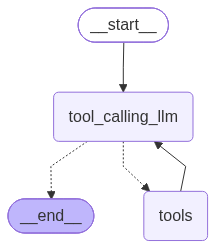

In [12]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

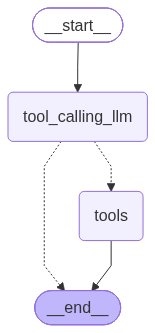

In [ ]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END) # ----->>> END

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
response=graph.invoke({"messages":"What is machine learning"})

In [21]:
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='9756e477-e1b9-4b68-b388-9efe3448af53'),
  AIMessage(content='Machine learning is a branch of artificial intelligence (AI) that focuses on creating systems that can learn from data, identify patterns, and make decisions or predictions with minimal explicit programming. Instead of being programmed with specific rules for every task, machine learning algorithms improve their performance automatically through experience—by analyzing examples and adjusting their internal parameters.\n\nKey aspects include:\n- **Learning from data**: Algorithms find patterns in datasets (e.g., images, text, numbers) to make predictions or classifications.\n- **Types of learning**: Supervised learning (labeled data), unsupervised learning (unlabeled data), reinforcement learning (learning via rewards/punishments).\n- **Applications**: Used in recommendation systems, speech recognition, medical diagno

In [16]:
response=graph.invoke({"messages":"10+10"})

In [17]:
response

{'messages': [HumanMessage(content='10+10', additional_kwargs={}, response_metadata={}, id='b62d7fc3-bdc8-404b-ab7b-580a8e441cfb'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "10+10". That\'s a simple addition. We can compute manually: 20. But we must use the available tool: add function. So we need to call functions.add with a=10, b=10. Then return result. Let\'s do that.', '_reasoning_api_fields': ['reasoning_content'], 'tool_calls': [{'id': 'chatcmpl-tool-b44c83aabfa3100b', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 10, "b": 10}'}}]}, response_metadata={'content': None, 'tool_calls': [{'id': 'chatcmpl-tool-b44c83aabfa3100b', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 10, "b": 10}'}}], 'role': 'assistant', 'reasoning_content': 'The user asks: "10+10". That\'s a simple addition. We can compute manually: 20. But we must use the available tool: add function. So we need to call functions.add with a=10,

In [25]:
response=graph.invoke({"messages":"what is 5 plus 30"})

response

{'messages': [HumanMessage(content='what is 5 plus 30', additional_kwargs={}, response_metadata={}, id='4b3220db-8052-4787-b01b-ac29965793b6'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "what is 5 plus 30". This is a simple addition problem: 5 + 30 = 35. We have a tool called add that adds two numbers. We should use it. The parameters are a and b. We can set a=5, b=30. Then call add. Let\'s do that.', '_reasoning_api_fields': ['reasoning_content'], 'tool_calls': [{'id': 'chatcmpl-tool-a1bf748a9b4f9800', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 5, "b": 30}'}}]}, response_metadata={'content': None, 'tool_calls': [{'id': 'chatcmpl-tool-a1bf748a9b4f9800', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 5, "b": 30}'}}], 'role': 'assistant', 'reasoning_content': 'The user asks: "what is 5 plus 30". This is a simple addition problem: 5 + 30 = 35. We have a tool called add that adds two numbers. We should use 

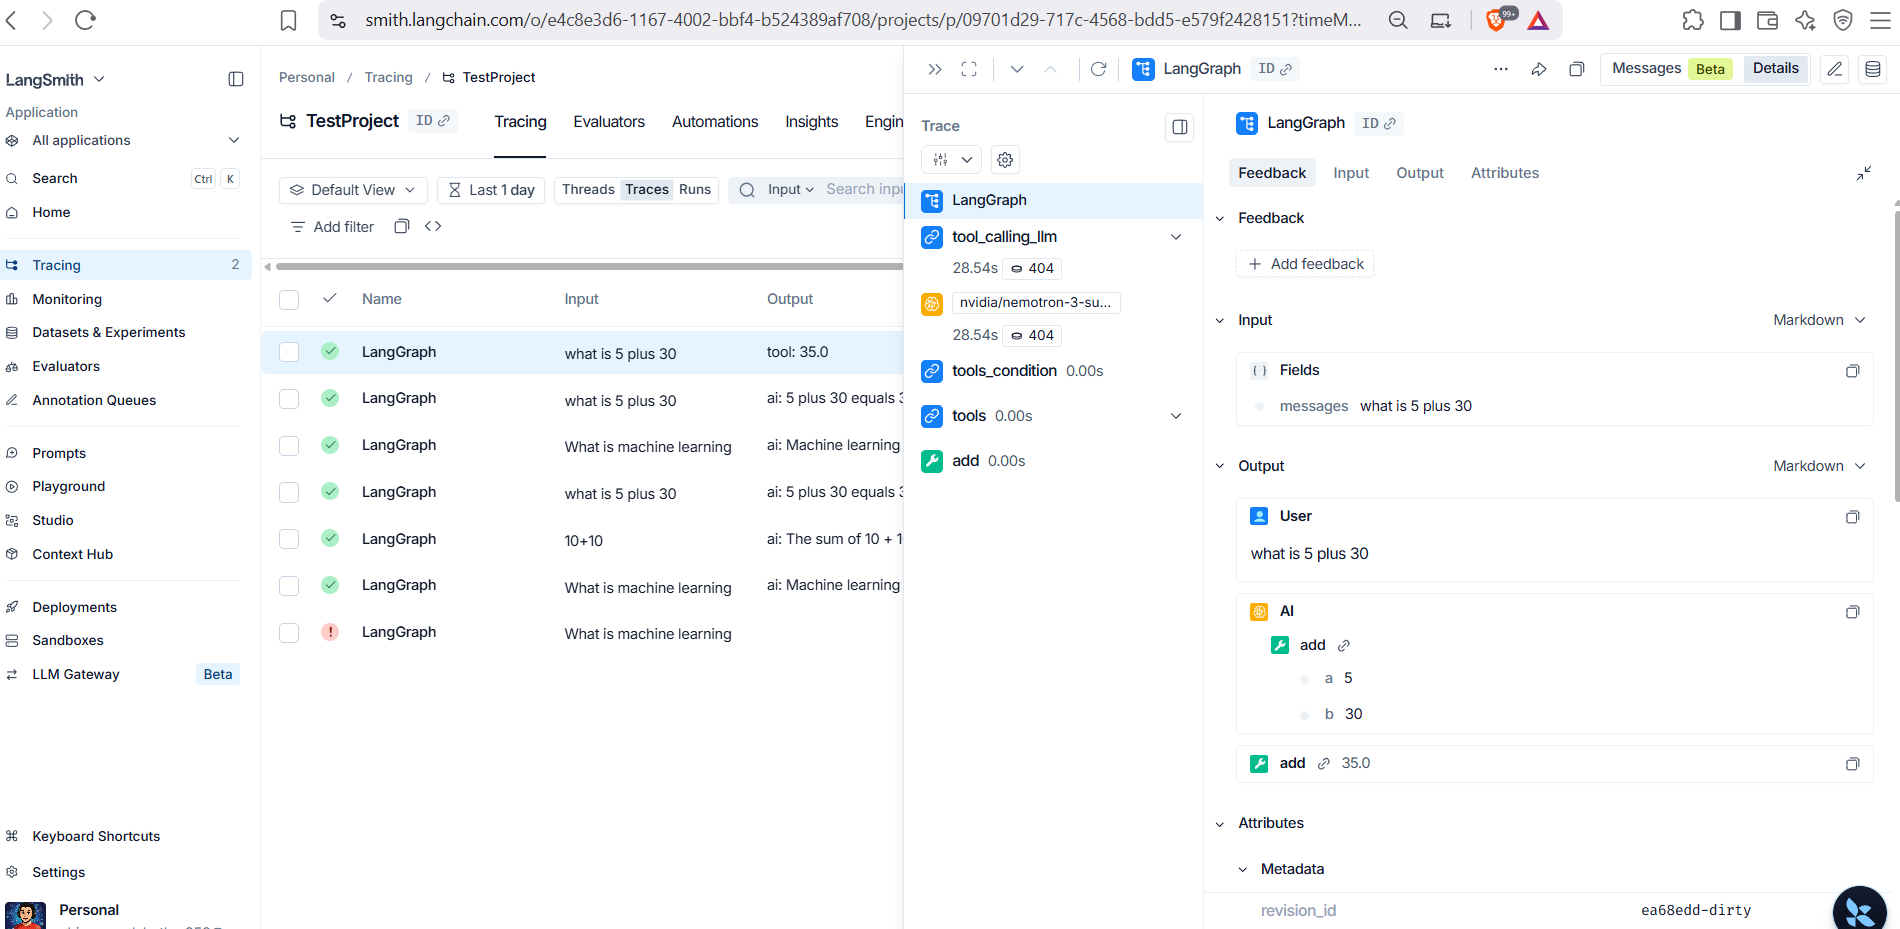

## react agent


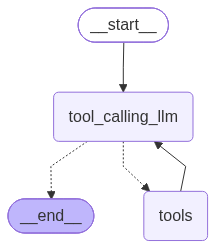

In [22]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [23]:
response=graph.invoke({"messages":"what is 5 plus 30"})

response

{'messages': [HumanMessage(content='what is 5 plus 30', additional_kwargs={}, response_metadata={}, id='e92765de-ce71-48af-88b3-08fb934cd38c'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user is asking "what is 5 plus 30". That\'s a simple addition: 5 + 30 = 35. I can use the add tool to compute this. Let me call the add function with a=5, b=30.', '_reasoning_api_fields': ['reasoning_content'], 'tool_calls': [{'id': 'chatcmpl-tool-89ddd168eb1ce778', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 5, "b": 30}'}}]}, response_metadata={'content': None, 'tool_calls': [{'id': 'chatcmpl-tool-89ddd168eb1ce778', 'type': 'function', 'function': {'name': 'add', 'arguments': '{"a": 5, "b": 30}'}}], 'role': 'assistant', 'reasoning_content': 'The user is asking "what is 5 plus 30". That\'s a simple addition: 5 + 30 = 35. I can use the add tool to compute this. Let me call the add function with a=5, b=30.', 'token_usage': {'prompt_tokens': 294, 'completi

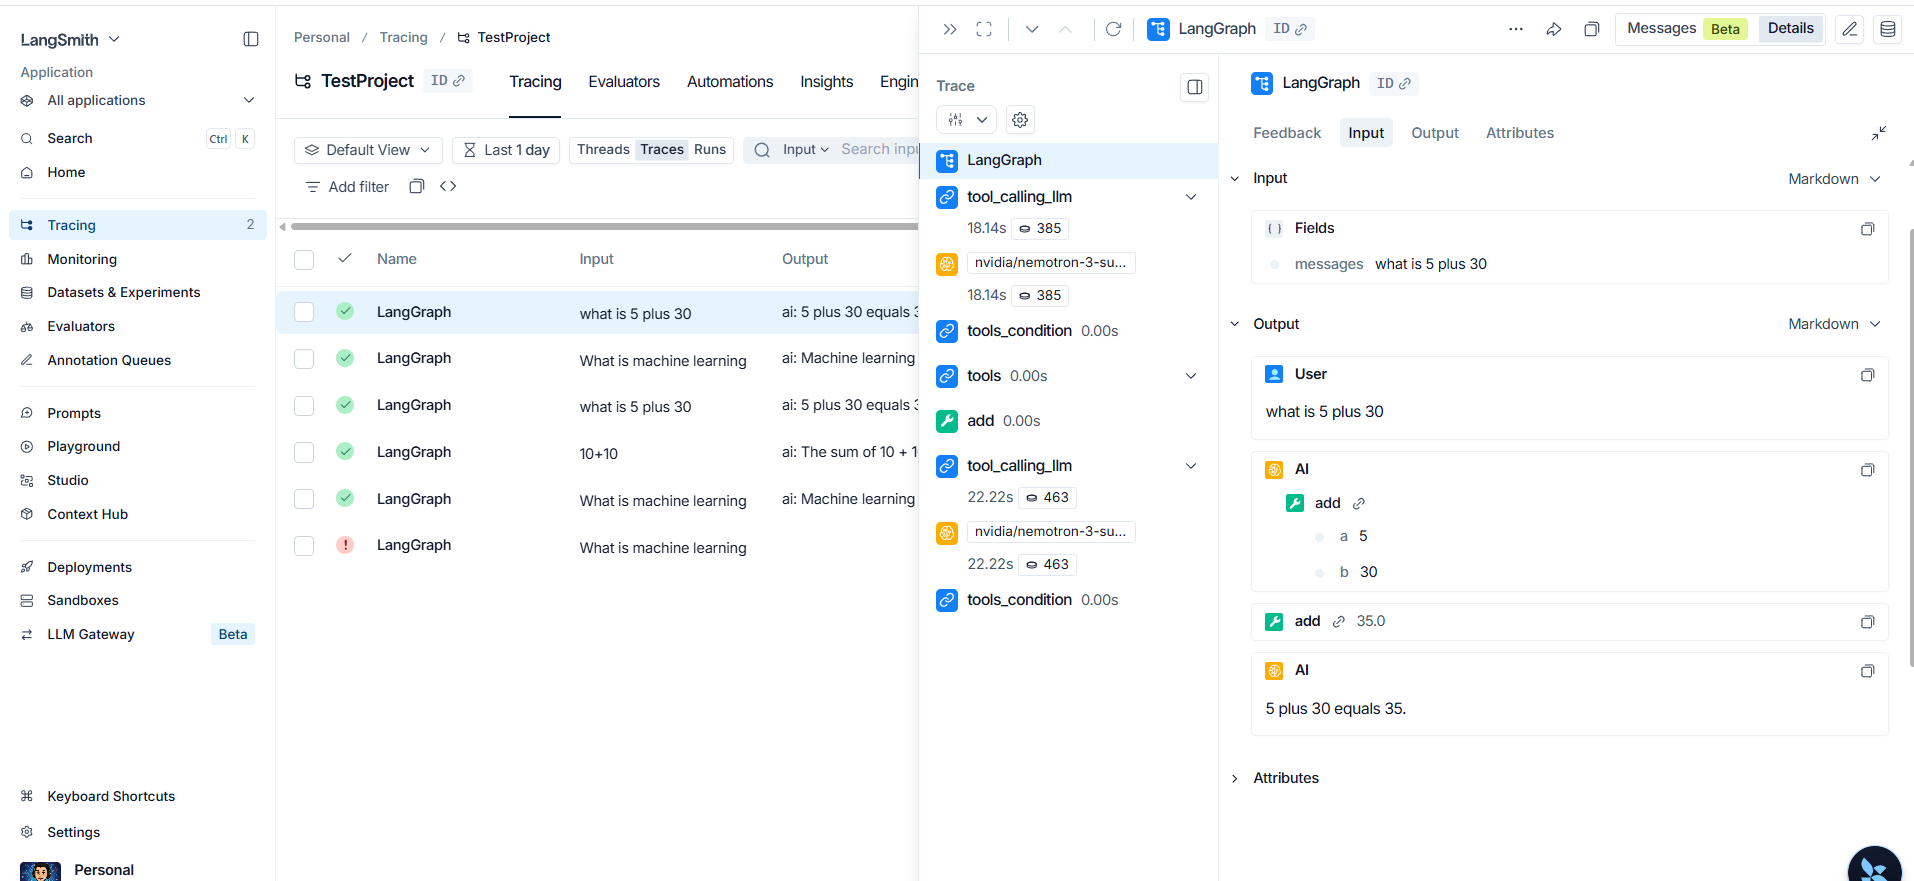

## Langgraph Studion


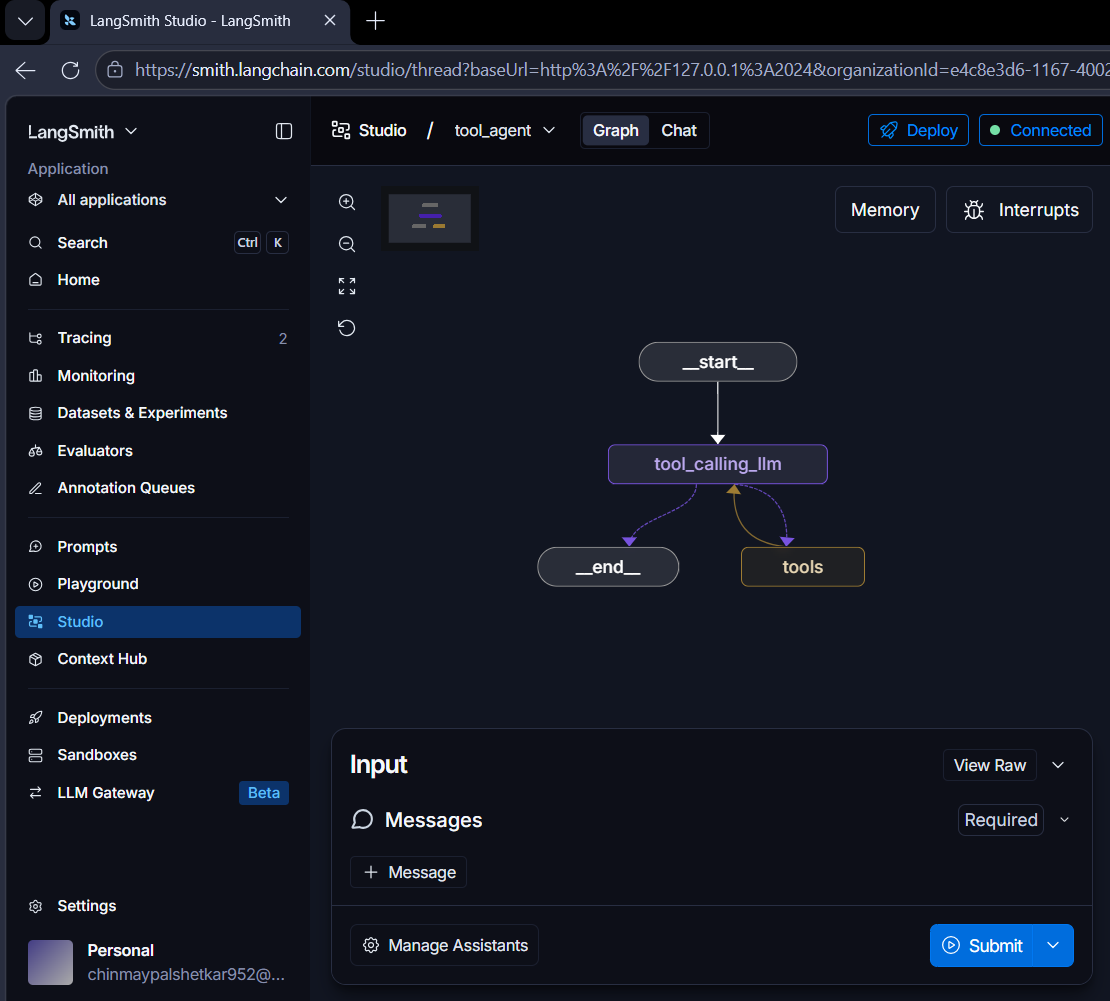

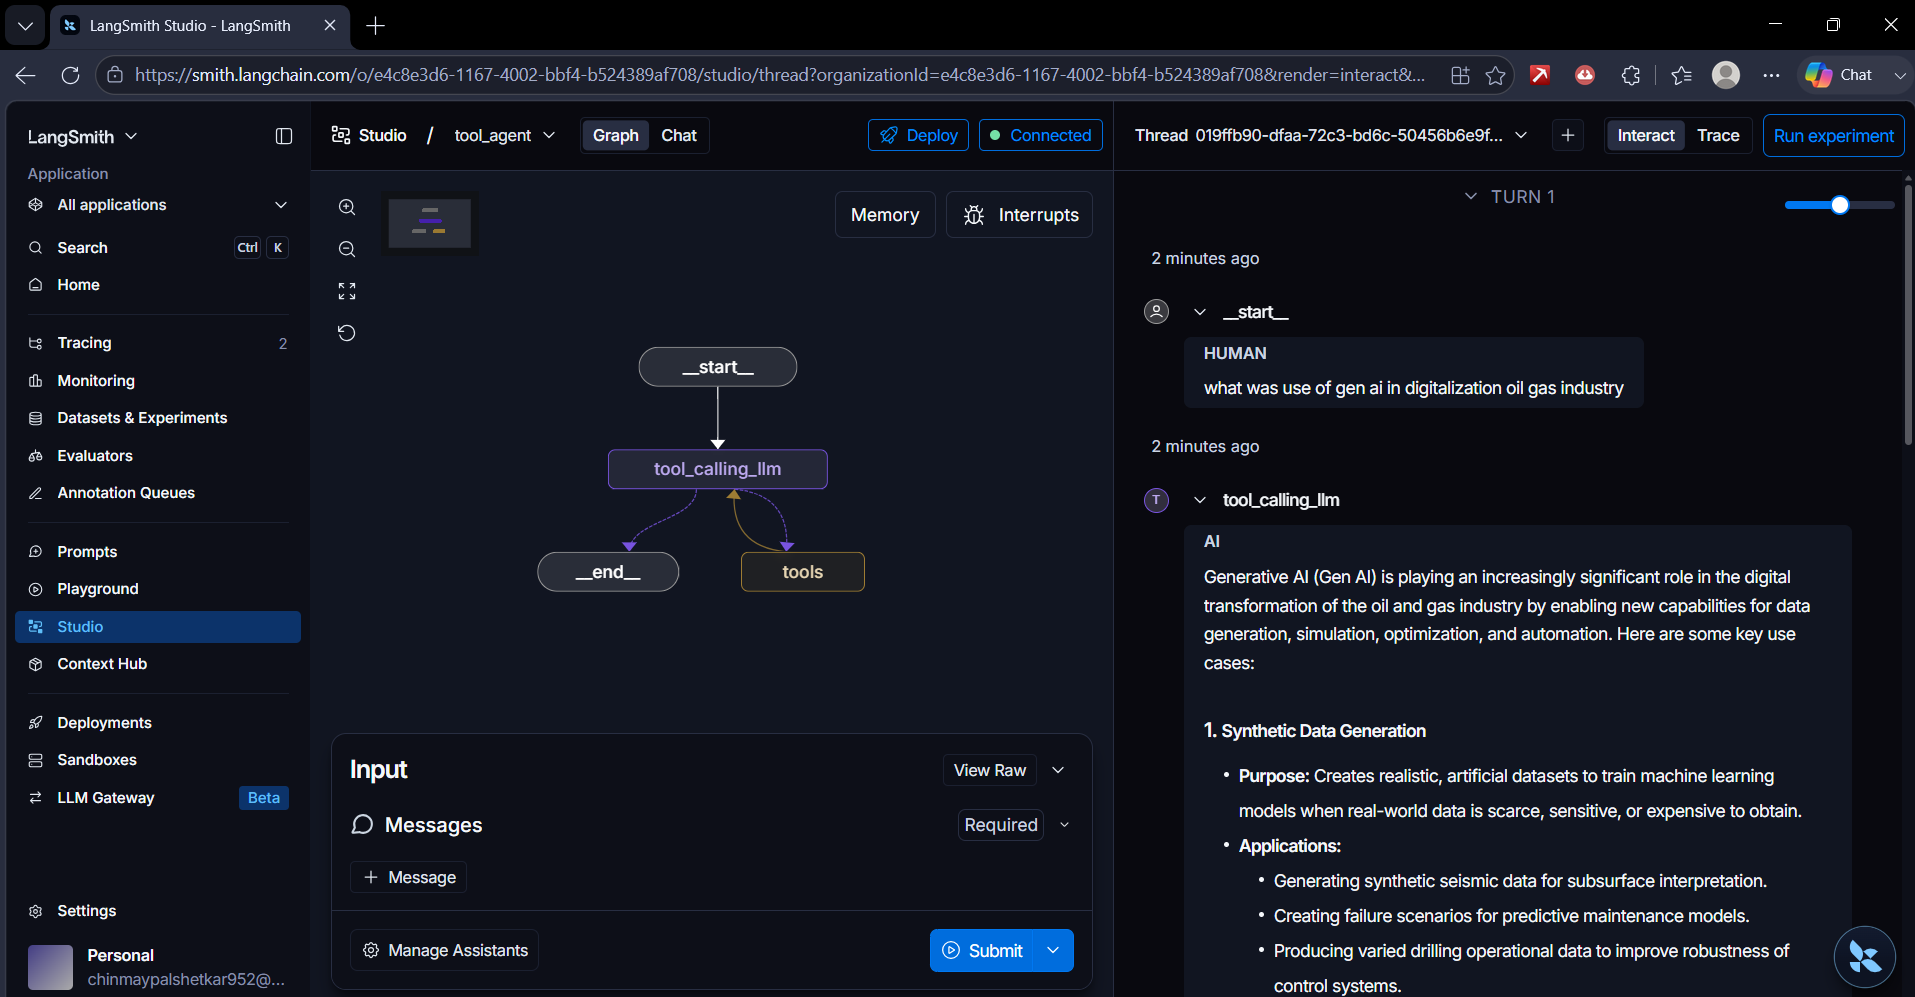